In [1]:
import numpy as np

from TimeSeriesGeneratorV2 import EventTimestampGenerator, EventSampleSpace, TimeSeriesGenerator

In [2]:
N = 6
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
noise_sds = [0]*N
no_occurrences_sds = [0]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", noise_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]
Occurrences: [1, 2, 3, 4, 5, 6]
Period standard deviations: [0, 0, 0, 0, 0, 0]
Number of occurrences standard deviations: [0, 0, 0, 0, 0, 0]


In [3]:
class ExampleETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals, noise_sds):
        super().__init__(occurrences, time_intervals)
        self.noise_sds = noise_sds
        
    def sample_noise (self, t):
        """Samples a timing interval"""
        return np.random.normal(loc=0, scale=self.noise_sds[self._find_interval_including_start(t)])


class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        return np.random.normal(loc=1, scale=0)

In [4]:
etg = ExampleETG(occurrences, time_intervals, noise_sds)
ess = ExampleSampleSpace()

self.spacings: [0.5, 0.3333333333333333, 0.25, 0.2, 0.16666666666666666, 0.14285714285714285]


In [5]:
def on_event(event):
    print(f"event: {event}")
    print("--------")

time_series_generator = TimeSeriesGenerator([(etg, ess)], on_event)
data = time_series_generator.run(N+1)
print("Generated data:", data)

latest_ts: 0, index_period: 0, period: 1.0, new_ideal_ts: 1.0, index_spacing: 0, spacing: 0.5, shifted: 0.5, noisy: 0.5
event: (0.5, 1.0)
--------
latest_ts: 1.0, index_period: 1, period: 0.5, new_ideal_ts: 1.5, index_spacing: 1, spacing: 0.3333333333333333, shifted: 1.3333333333333333, noisy: 1.3333333333333333
event: (1.3333333333333333, 1.0)
--------
latest_ts: 1.5, index_period: 1, period: 0.5, new_ideal_ts: 2.0, index_spacing: 1, spacing: 0.3333333333333333, shifted: 1.8333333333333333, noisy: 1.8333333333333333
event: (1.8333333333333333, 1.0)
--------
latest_ts: 2.0, index_period: 2, period: 0.3333333333333333, new_ideal_ts: 2.3333333333333335, index_spacing: 2, spacing: 0.25, shifted: 2.25, noisy: 2.25
event: (2.25, 1.0)
--------
latest_ts: 2.3333333333333335, index_period: 2, period: 0.3333333333333333, new_ideal_ts: 2.666666666666667, index_spacing: 2, spacing: 0.25, shifted: 2.5833333333333335, noisy: 2.5833333333333335
event: (2.5833333333333335, 1.0)
--------
latest_ts: 2.

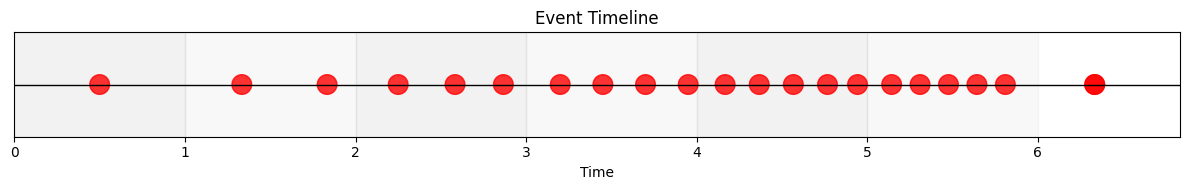

In [6]:
import matplotlib.pyplot as plt

# Assume `data` is a list of (time, scale) tuples,
# and `time_intervals` is a list of (start, end) tuples, already defined.

# Unpack times and scales
times, scales = zip(*data)

# All events sit on the same horizontal line
ys = [0] * len(times)

# Map scales to marker sizes (adjust the multiplier as needed)
marker_sizes = [s * 200 for s in scales]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 2))

# Draw baseline timeline
ax.hlines(0, min(times) - 0.5, max(times) + 0.5, color='black', linewidth=1)

# Shade each period for context
for idx, (start, end) in enumerate(time_intervals):
    alpha = 0.1 if idx % 2 == 0 else 0.05
    ax.axvspan(start, end, color='gray', alpha=alpha)

# Plot events as red circles
ax.scatter(times, ys, s=marker_sizes, color='red', alpha=0.8)

# Hide y-axis ticks and labels
ax.set_yticks([])

# Labels and title
ax.set_xlabel('Time')
ax.set_title('Event Timeline')

# Set plot limits
ax.set_xlim(min(times) - 0.5, max(times) + 0.5)
ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()


In [7]:
import matplotlib.pyplot as plt


def plot_multiple_timelines(data_list, time_intervals, titles, colors):
    """
    Plot multiple event timelines stacked vertically.

    Parameters:
    - data_list: List of data sources, each being a list of (time, scale) tuples.
    - time_intervals: List of (start, end) tuples defining shaded periods.
    - titles: List of titles for each subplot.
    - colors: List of colors for the markers of each subplot.

    Each timeline will be drawn on its own subplot, sharing the same x-axis.
    """
    n = len(data_list)
    if not (len(titles) == len(colors) == n):
        raise ValueError("data_list, titles and colors must have the same length")

    # Create subplots, one row per data source
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    # Determine global x-limits from all data
    all_times = [t for data in data_list for t, _ in data]
    xmin, xmax = min(all_times) - 0.5, max(all_times) + 0.5

    for i, (data, title, color) in enumerate(zip(data_list, titles, colors)):
        times, scales = zip(*data)
        ys = [0] * len(times)
        marker_sizes = [s * 200 for s in scales]

        ax = axes[i]
        # Draw baseline timeline
        ax.hlines(0, xmin, xmax, color='black', linewidth=1)

        # Shade each period for context
        for idx, (start, end) in enumerate(time_intervals):
            alpha = 0.1 if idx % 2 == 0 else 0.05
            ax.axvspan(start, end, color='gray', alpha=alpha)

        # Plot events
        ax.scatter(times, ys, s=marker_sizes, color=color, alpha=0.8)

        # Hide y-axis
        ax.set_yticks([])
        ax.set_ylabel(title, rotation=0, labelpad=40, va='center')

        # Only label x-axis on the bottom plot
        if i == n - 1:
            ax.set_xlabel('Time')

        # Set vertical limits to center the line
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(-0.5, 0.5)

    plt.tight_layout()
    plt.show()

data_list = [data, data_ideal, data_shifted, data_ideal_shifted]
titles = ['Data', 'Ideal Data', 'Shifted Data', 'Ideal \n Shifted Data']
colors = ['red', 'blue', 'green', 'orange']
plot_multiple_timelines(data_list, time_intervals, titles, colors)

NameError: name 'data_ideal' is not defined

In [ ]:
from Analytics import count_number_of_occurrences_in_intervals
print(data)
count_number_of_occurrences_in_intervals(time_intervals, data_shifted)

[(0.18066827942846742, 1.0), (0.761384998728129, 1.0), (1.650703518870442, 1.0), (2.5811190835774873, 1.0), (2.9476025026400077, 1.0), (3.516195185129084, 1.0), (3.607124321212676, 1.0), (4.007016805985434, 1.0), (4.535308644174576, 1.0), (5.252980452094895, 1.0), (5.746672772721418, 1.0), (6.704821380001984, 1.0), (7.839964176894488, 1.0), (8.297669876885259, 1.0), (8.441356864226726, 1.0), (10.141304187885531, 1.0), (11.226139581457563, 1.0), (11.231073715369126, 1.0), (11.27789701164624, 1.0), (11.312938002985247, 1.0), (11.634117552823266, 1.0)]


[1, 1, 2, 3, 1, 2]